#### Tissera Ana Paula - `Notebook TP2`

##### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

## 1. **Diagnóstico de Cáncer de Mama**

### `1.1)` Análisis exploratorio de los datos

##### Cargar data

In [ ]:
dev_path_1 = "data/Problem_1/raw/cell_diagnosis_dev.csv"
imbalanced_dev_path_1 = "data/Problem_1/raw/cell_diagnosis_dev_imbalanced.csv" 
test_path_1 = "data/Problem_1/raw/cell_diagnosis_test.csv"
imbalanced_test_path_1 = "data/Problem_1/raw/cell_diagnosis_test_imbalanced.csv"

cell_diagnosis_dev_df = pd.read_csv(dev_path_1, na_values=["NaN", "N/A", ""])
cell_diagnosis_imbalanced_dev_df = pd.read_csv(imbalanced_dev_path_1, na_values=["NaN", "N/A", ""])
cell_diagnosis_test_df = pd.read_csv(test_path_1, na_values=["NaN", "N/A", ""])
cell_diagnosis_imbalanced_test_df = pd.read_csv(imbalanced_test_path_1, na_values=["NaN", "N/A", ""])

##### Muestra

In [3]:
print('shape = ', cell_diagnosis_dev_df.shape)
cell_diagnosis_dev_df.sample(5)

shape =  (1663, 15)


,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis,CellType,GeneticMutation
153,70.265174,NaN,1.437508,21.764445,30.726391,0.497767,2.813240,2.295947,64.317968,NaN,5.172661,38.334345,1.0,???,Absnt
1103,539.318913,2.714927,12.757638,189.956489,178.122172,4.460697,32.154247,14.900221,405.706416,NaN,29.012258,227.889137,0.0,Mesnchymal,Absnt
1151,66.050114,0.526793,1.476374,22.571401,27.063077,0.464079,3.352326,2.416764,NaN,79.752679,4.674716,42.762136,0.0,???,Presnt
1387,67.221531,0.432035,1.470058,22.272767,26.270490,NaN,NaN,2.466093,61.663391,78.607578,NaN,41.924013,0.0,Epthlial,Presnt
1277,64.197880,NaN,1.442745,23.828628,26.543297,0.521669,3.235270,2.559560,60.369237,79.284326,4.488213,40.306236,0.0,???,Absnt


In [4]:
TARGET_COLUMN = "Diagnosis"

##### Valores faltantes

In [5]:
from src.analysis import missing_values

In [6]:
missing_values(cell_diagnosis_dev_df, "Dev")

### Valores faltantes por columna en el **Dev** Set

| Columna | Valores faltantes |
|---------|-------------------|
| CellSize | 330 |
| MitosisRate | 320 |
| NuclearMembrane | 320 |
| CellShape | 316 |
| CytoplasmSize | 316 |
| Vascularization | 316 |
| InflammationMarkers | 305 |
| GrowthFactor | 304 |
| NucleusDensity | 301 |
| ChromatinTexture | 297 |
| CellAdhesion | 294 |
| OxygenSaturation | 288 |
| CellType | 256 |
| Diagnosis | 0 |
| GeneticMutation | 0 |


In [7]:
missing_values(cell_diagnosis_imbalanced_dev_df, "Imbalanced Dev")

### Valores faltantes por columna en el **Imbalanced Dev** Set

| Columna | Valores faltantes |
|---------|-------------------|
| CytoplasmSize | 245 |
| MitosisRate | 240 |
| CellShape | 237 |
| CellSize | 236 |
| GrowthFactor | 230 |
| Vascularization | 230 |
| NuclearMembrane | 225 |
| NucleusDensity | 220 |
| OxygenSaturation | 220 |
| InflammationMarkers | 219 |
| CellAdhesion | 214 |
| ChromatinTexture | 212 |
| CellType | 184 |
| Diagnosis | 0 |
| GeneticMutation | 0 |


In [8]:
missing_values(cell_diagnosis_test_df, "Test")

### Valores faltantes por columna en el **Test** Set

| Columna | Valores faltantes |
|---------|-------------------|
| CellShape | 41 |
| GrowthFactor | 40 |
| Vascularization | 40 |
| MitosisRate | 36 |
| InflammationMarkers | 36 |
| CellSize | 35 |
| ChromatinTexture | 35 |
| CytoplasmSize | 33 |
| NucleusDensity | 32 |
| OxygenSaturation | 31 |
| CellType | 31 |
| CellAdhesion | 29 |
| NuclearMembrane | 25 |
| Diagnosis | 0 |
| GeneticMutation | 0 |


In [9]:
missing_values(cell_diagnosis_imbalanced_test_df, "Imbalanced Test")

### Valores faltantes por columna en el **Imbalanced Test** Set

| Columna | Valores faltantes |
|---------|-------------------|
| GrowthFactor | 32 |
| CellShape | 31 |
| MitosisRate | 31 |
| Vascularization | 31 |
| NucleusDensity | 28 |
| InflammationMarkers | 28 |
| CellSize | 25 |
| ChromatinTexture | 25 |
| OxygenSaturation | 25 |
| CytoplasmSize | 23 |
| CellType | 21 |
| CellAdhesion | 19 |
| NuclearMembrane | 16 |
| Diagnosis | 0 |
| GeneticMutation | 0 |


#### **Variables Categóricas**

### Distribución de las variables, su correlación con el target y rangos posibles de cada una.

#### Rangos

In [10]:
from src.analysis import describe_feature_ranges, detect_outliers

In [11]:
describe_feature_ranges([cell_diagnosis_dev_df, cell_diagnosis_imbalanced_dev_df, cell_diagnosis_test_df, cell_diagnosis_imbalanced_test_df])

### Rango de valores por feature en todos los datasets:
| Feature             | Tipo       | Rango o Valores Únicos            |
|:--------------------|:-----------|:----------------------------------|
| CellSize            | Numérica   | [-100.00 → 1000.00]               |
| CellShape           | Numérica   | [-3.51 → 5.05]                    |
| NucleusDensity      | Numérica   | [-3.00 → 50.00]                   |
| ChromatinTexture    | Numérica   | [10.00 → 263.79]                  |
| CytoplasmSize       | Numérica   | [5.00 → 299.35]                   |
| CellAdhesion        | Numérica   | [-4.46 → 5.03]                    |
| MitosisRate         | Numérica   | [-50.00 → 100.00]                 |
| NuclearMembrane     | Numérica   | [-3.44 → 24.87]                   |
| GrowthFactor        | Numérica   | [-50.00 → 563.62]                 |
| OxygenSaturation    | Numérica   | [-10.00 → 807.18]                 |
| Vascularization     | Numérica   | [-1.00 → 54.51]                   |
| InflammationMarkers | Numérica   | [0.00 → 440.90]                   |
| Diagnosis           | Categórica | [0.0, 1.0]                        |
| CellType            | Categórica | ['???', 'Epthlial', 'Mesnchymal'] |
| GeneticMutation     | Categórica | ['Absnt', 'Presnt']               |

In [12]:
valid_ranges = {
    # 'CellSizeNormal': (0, 150), # μm (micrómetro) no puede ser negativo, ya que es una unidad de medida que se usa para expresar longitudes
    # El óvulo humano es la célula más grande del cuerpo humano. 150 micrómetros (µm) es lo máximo que puede medir
    'CellSize': (0, 150),
    # 'CellShape': (0, 1), # es un ratio
    'CellShape': (0, 1),
    'NucleusDensity': (0, 2.7),
    'ChromatinTexture': (15, 30),
    # 'CytoplasmSizeNormal': (0, 150), # no puede ser más grande que el tamaño de la célula
    'CytoplasmSize': (0, 100),
    'CellAdhesion': (0, 1),
    'MitosisRate': (0, 6.5),
    'NuclearMembrane': (1, 5),
    'GrowthFactor': (0, 150), # ng/mL nanogramos por mililitro no puede ser negativo, es una concentración # hasta 50
    'OxygenSaturation': (0, 100),
    'Vascularization': (0, 10),
    'InflammationMarkers': (0, 100)
}


##### `Cell diagnosis Dev Set`

In [13]:
dev_outliers = detect_outliers(cell_diagnosis_dev_df, valid_ranges)

### Cantidad de outliers por feature:
| Feature             |   Cantidad de Outliers |
|:--------------------|-----------------------:|
| CellSize            |                     61 |
| CellShape           |                     61 |
| NucleusDensity      |                     79 |
| ChromatinTexture    |                     48 |
| CytoplasmSize       |                     42 |
| CellAdhesion        |                     57 |
| MitosisRate         |                     90 |
| NuclearMembrane     |                     51 |
| GrowthFactor        |                     70 |
| OxygenSaturation    |                     67 |
| Vascularization     |                     38 |
| InflammationMarkers |                     38 |
| Diagnosis           |                      0 |
| CellType            |                      0 |
| GeneticMutation     |                      0 |

In [14]:
from src.preprocessing import handle_missing_values, one_hot_encode_column, binary_encode_column, convert_columns_to_int

In [15]:
diagnosis_dev_filled = handle_missing_values(
    data=cell_diagnosis_dev_df,
    target_col="Diagnosis",
    train=True,
    reference=None,
    intervals=valid_ranges,
    stats_dict=None,
    neighbors=5,
)

KNN imputing: 100%|██████████| 1556/1556 [00:03<00:00, 396.33it/s]


In [16]:
correcciones_celltype = {
    'Epthlial': 'Epithelial',
    'Mesnchymal': 'Mesenchymal',
    '???': 'Unknown'
}
mapeo_mutacion = {
    'Absnt': 0,
    'Presnt': 1
}

def preprocess_diagnosis_data(df_filled):
    df_filled_OHE = one_hot_encode_column(df_filled, 'CellType', corrections=correcciones_celltype)
    df_filled_OHE_BE = binary_encode_column(df_filled_OHE, 'GeneticMutation', mapeo_mutacion)
    df_filled_OHE_BE = convert_columns_to_int(df_filled_OHE_BE, ['Diagnosis'])
    return df_filled_OHE_BE

diagnosis_dev_filled_OHE_BE = preprocess_diagnosis_data(diagnosis_dev_filled)

diagnosis_dev_filled_OHE_BE.sample(5)

,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis,GeneticMutation,CellType_Epithelial,CellType_Mesenchymal,CellType_Unknown
388,67.552045,0.482838,1.414745,22.097352,29.241327,0.467980,2.986771,2.250154,60.728500,80.195157,4.979279,41.056804,1,1,0,0,1
41,64.133007,0.507602,1.472312,24.184436,26.480613,0.460715,3.508344,2.482882,56.474635,80.300194,5.024525,40.665522,0,1,0,1,0
896,69.682445,0.508870,1.387574,22.579667,28.807514,0.479579,2.882548,2.287605,60.727422,81.956827,5.641818,39.130477,1,1,0,1,0
595,69.054066,0.498176,1.440374,22.008350,28.265286,0.472963,3.075327,2.393248,60.173937,80.120143,5.052838,40.585506,0,1,1,0,0
1582,75.058455,0.489147,1.376069,23.762191,28.733629,0.460954,2.890531,2.060079,61.772543,80.299522,4.728431,34.057915,0,0,0,1,0


Evaluamos si quedaron outliers en el nuevo dataset.

In [17]:
dev_outliers_filled_OHE_BE = detect_outliers(diagnosis_dev_filled_OHE_BE, valid_ranges)

### Cantidad de outliers por feature:
| Feature              |   Cantidad de Outliers |
|:---------------------|-----------------------:|
| CellSize             |                      0 |
| CellShape            |                      0 |
| NucleusDensity       |                      0 |
| ChromatinTexture     |                      0 |
| CytoplasmSize        |                      0 |
| CellAdhesion         |                      0 |
| MitosisRate          |                      0 |
| NuclearMembrane      |                      0 |
| GrowthFactor         |                      0 |
| OxygenSaturation     |                      0 |
| Vascularization      |                      0 |
| InflammationMarkers  |                      0 |
| Diagnosis            |                      0 |
| GeneticMutation      |                      0 |
| CellType_Epithelial  |                      0 |
| CellType_Mesenchymal |                      0 |
| CellType_Unknown     |                      0 |

In [18]:
from src.plot import plot_features_with_correlation, plot_correlations_with_target, plot_pairplot

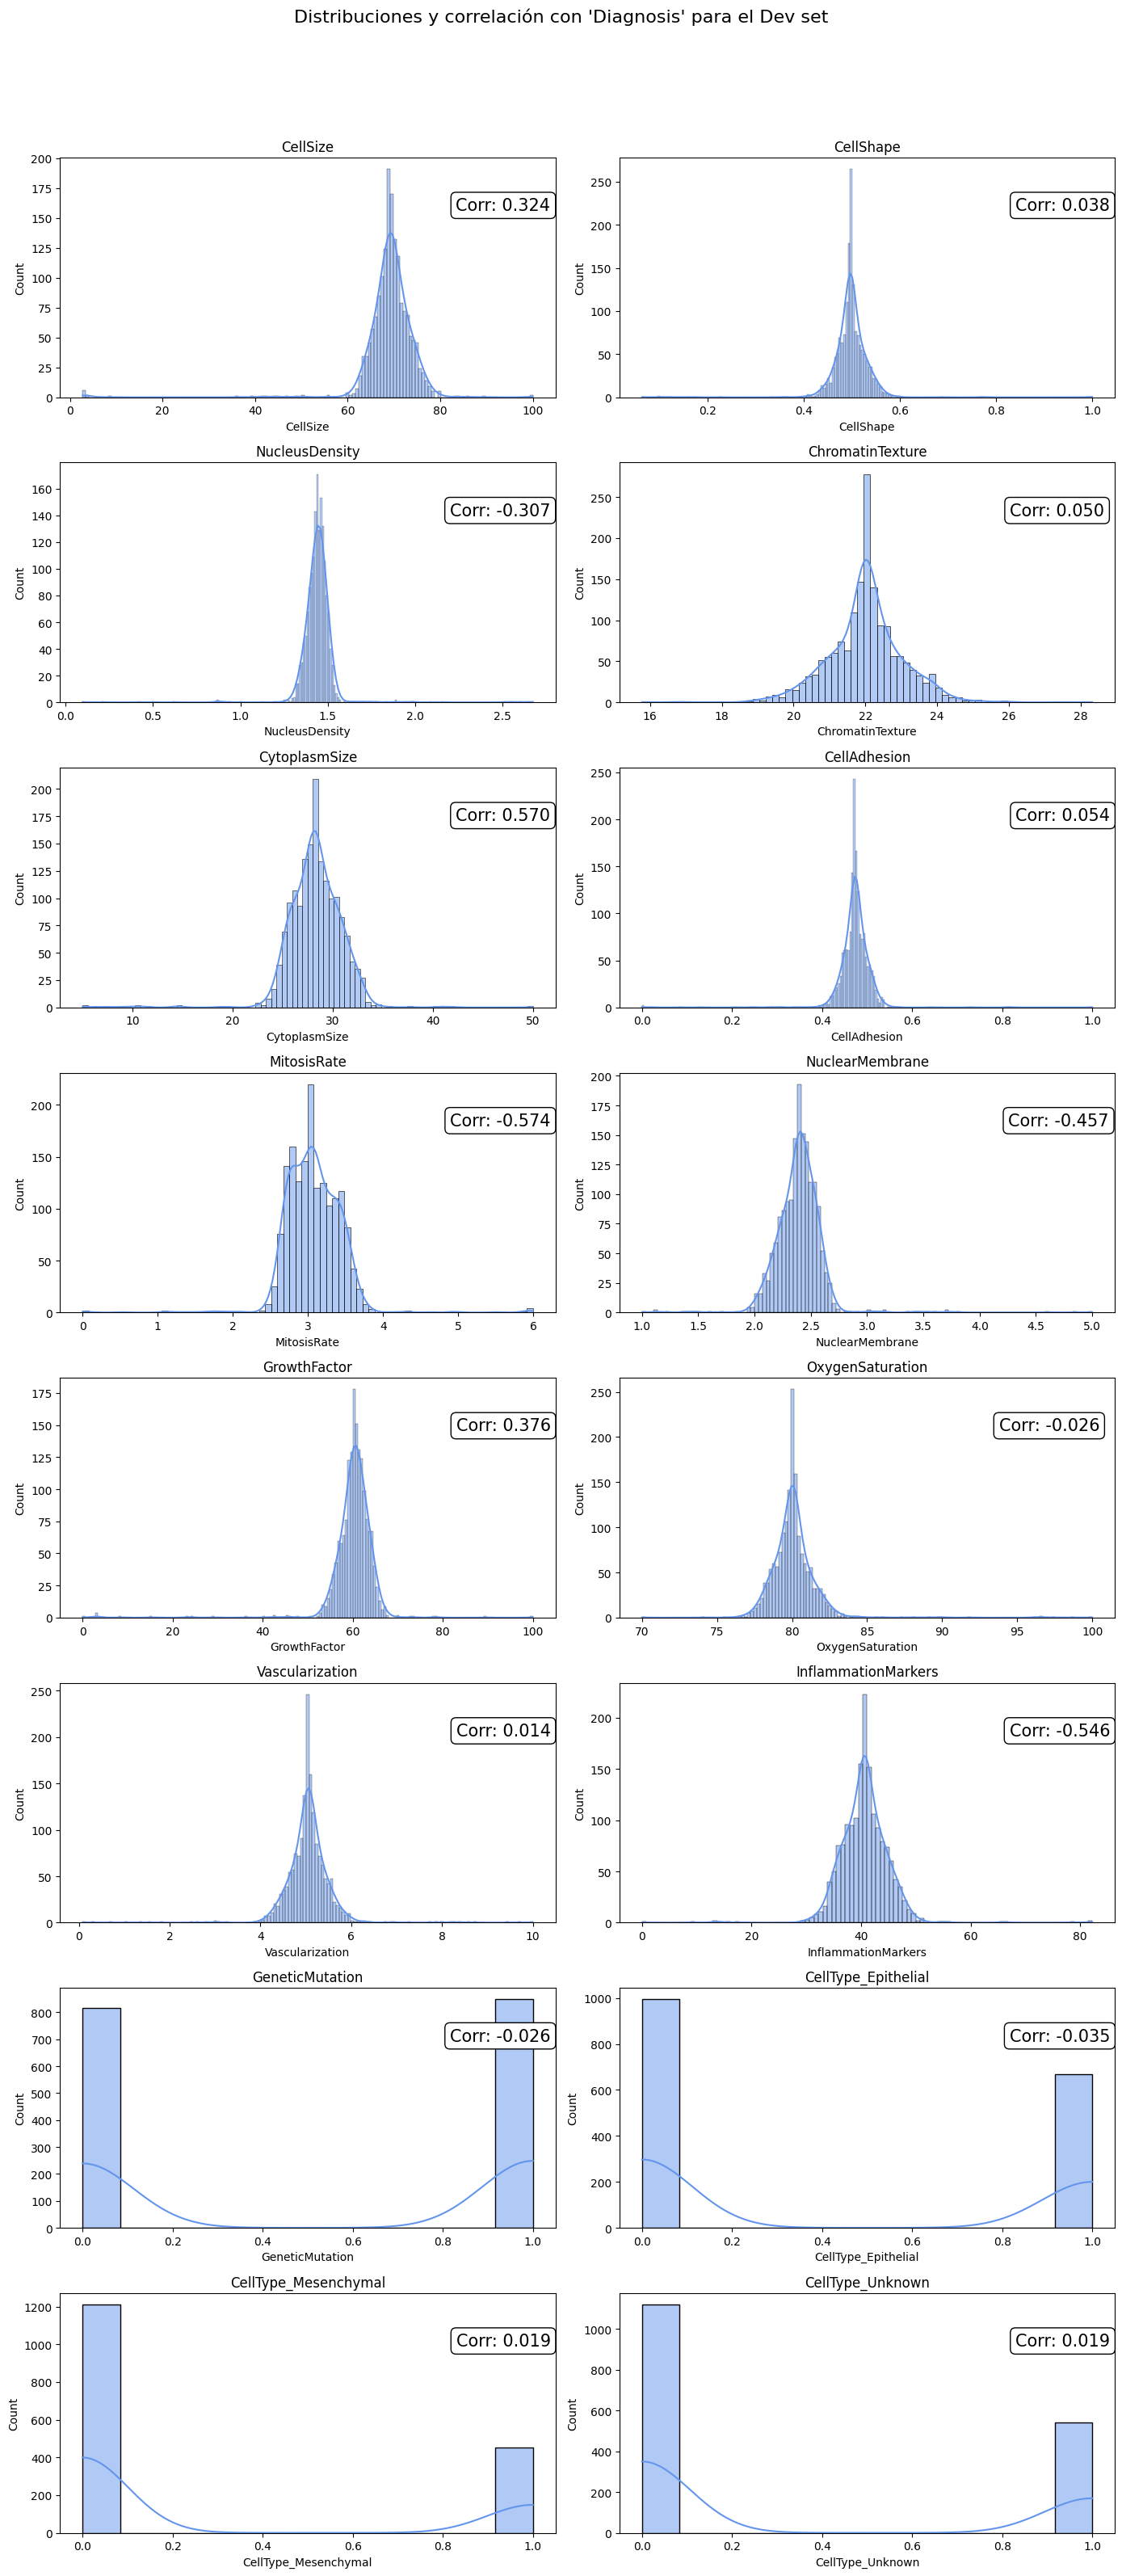

In [19]:
plot_features_with_correlation(diagnosis_dev_filled_OHE_BE, "Dev set", target_col="Diagnosis", batch_size=16)

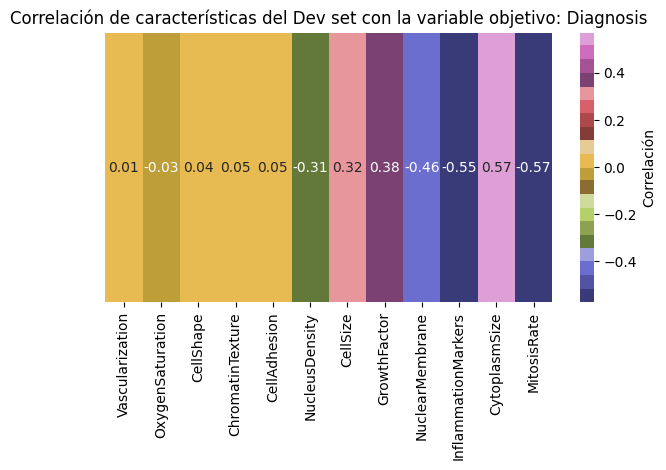

In [20]:
plot_correlations_with_target(diagnosis_dev_filled_OHE_BE, "Dev set", target_col="Diagnosis")

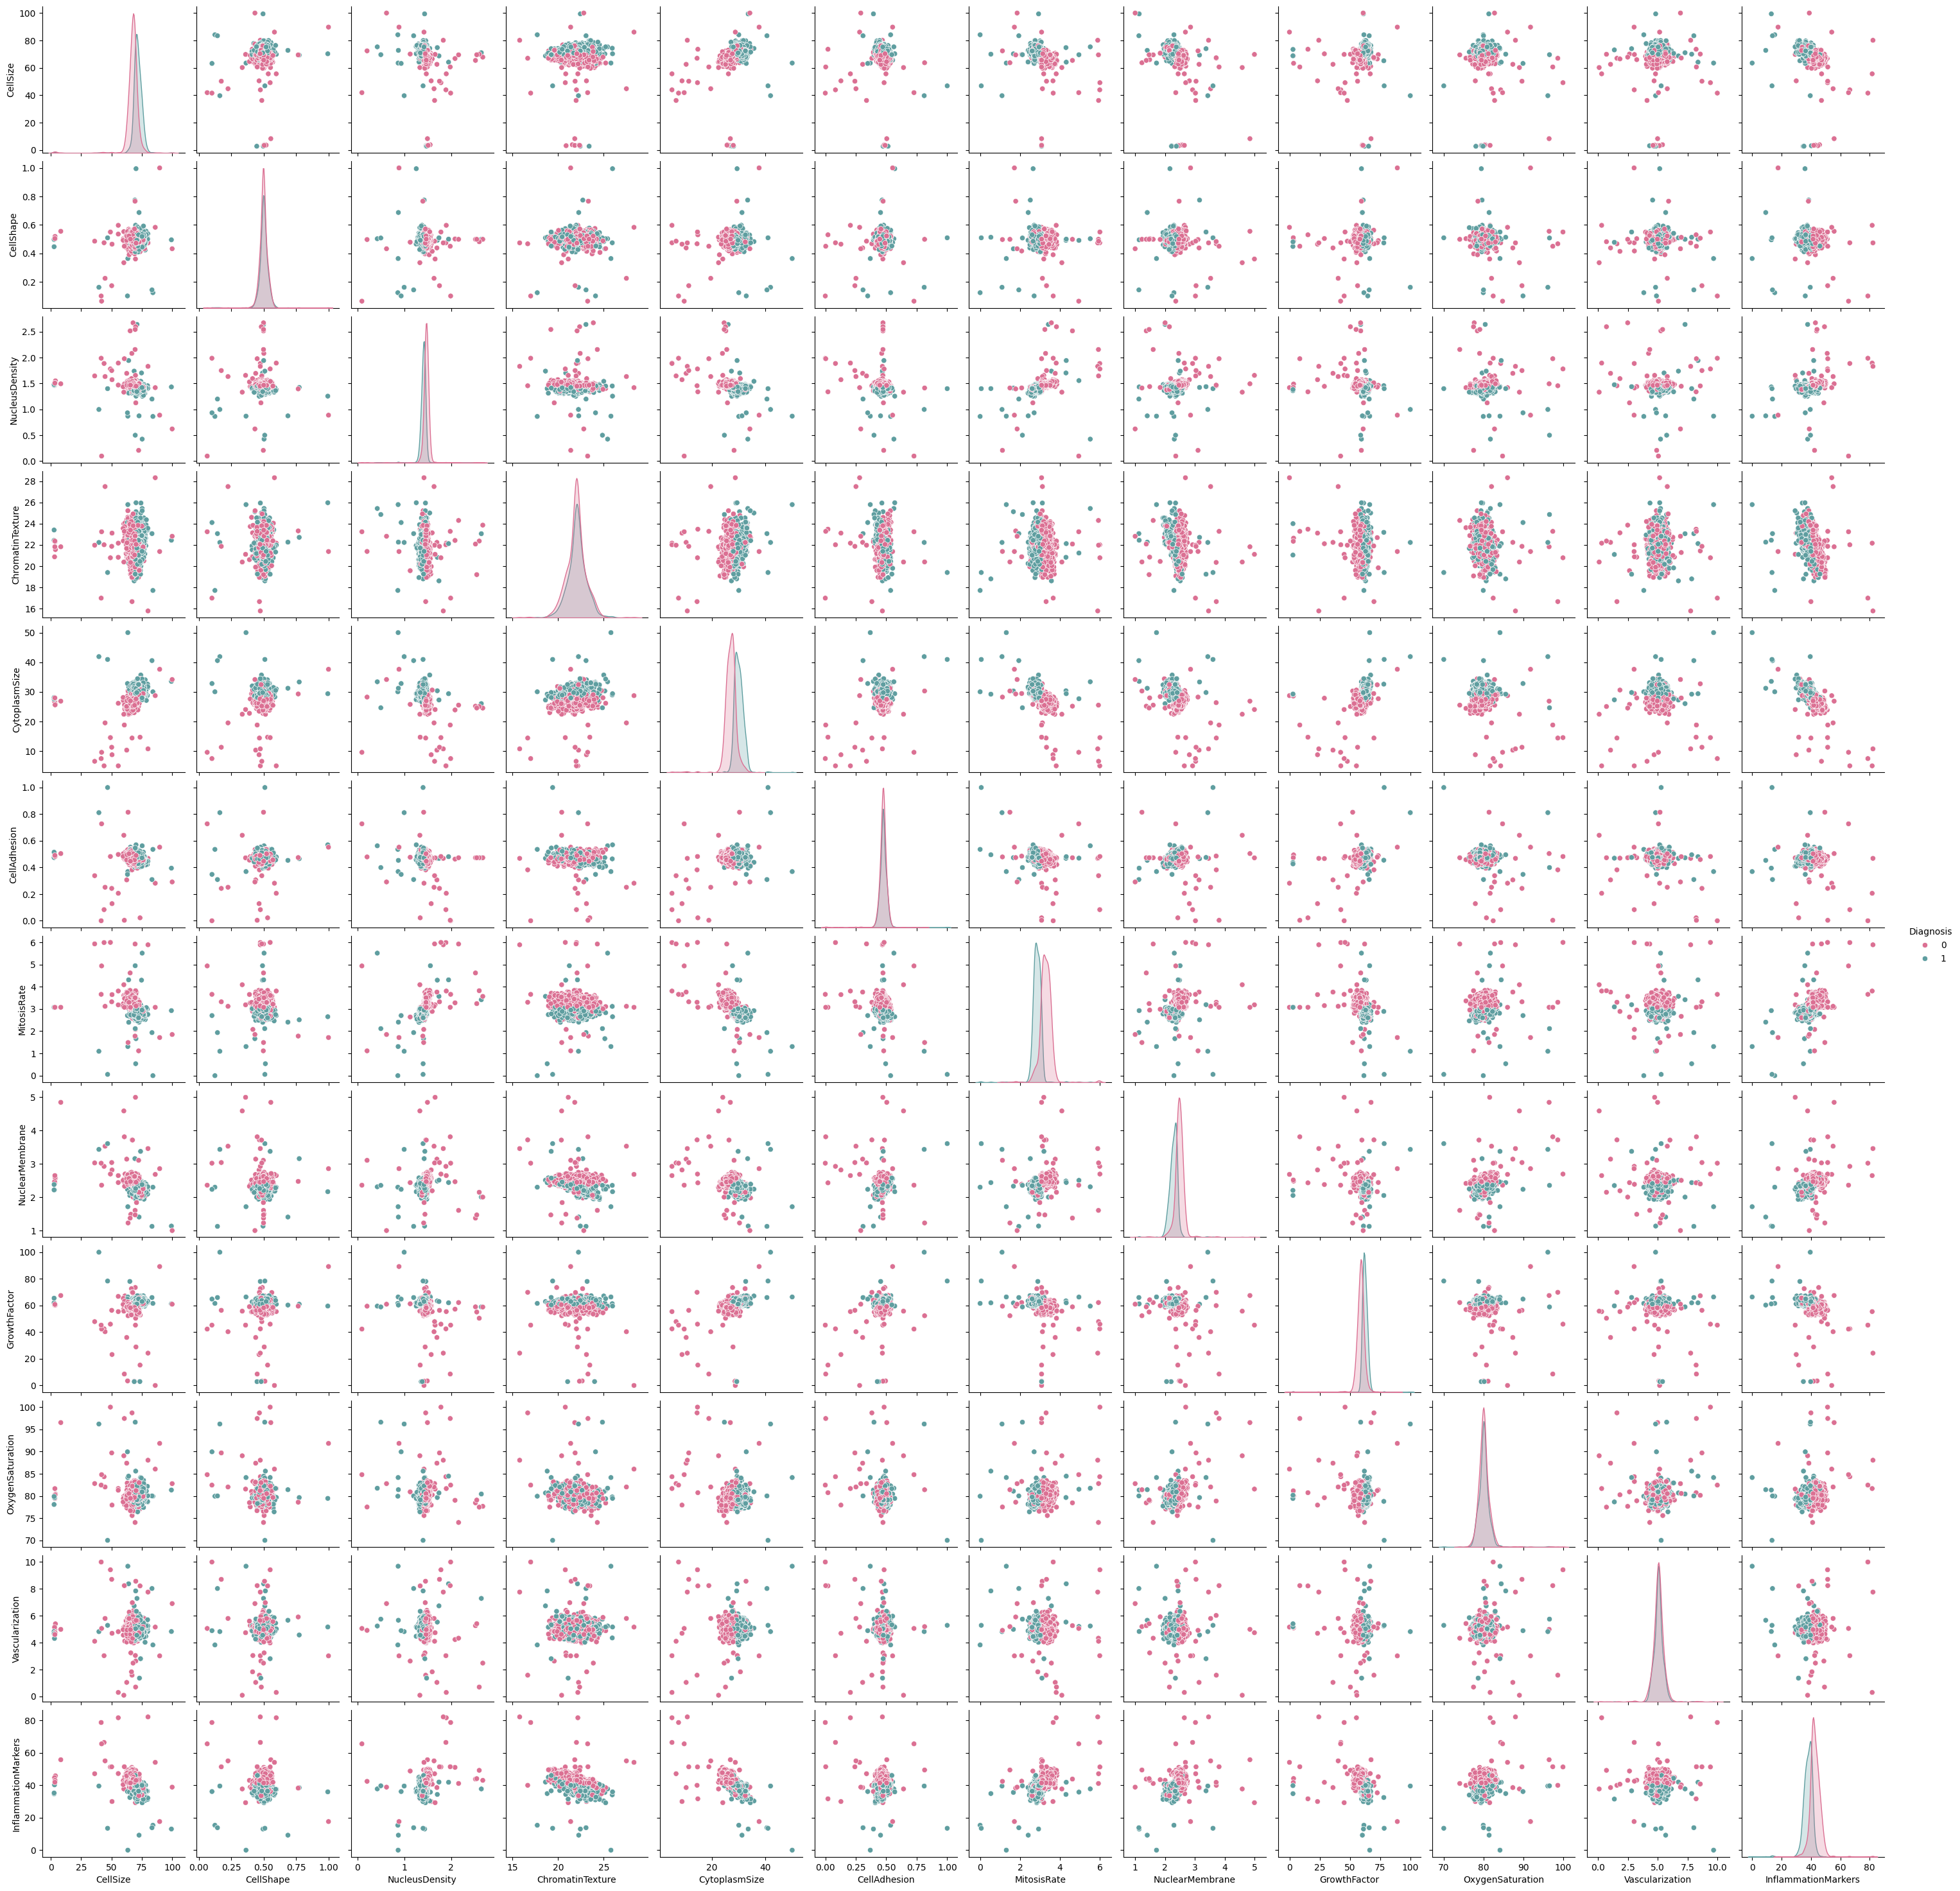

In [21]:
categorical_variables = ["GeneticMutation", "CellType_Epithelial", "CellType_Mesenchymal", "CellType_Unknown"]
plot_pairplot(diagnosis_dev_filled_OHE_BE.drop(columns=categorical_variables), TARGET_COLUMN)

## `1.2)` clase LogisticRegression implementada en scr.models

In [22]:
from src.models import LogisticRegression
from src.metrics import report_metrics, plot_roc_curve, plot_pr_curve, f1_score
from src.preprocessing import normalize_dataframe
from src.data_splitting import split_train_validation

In [23]:
RANDOM_STATE = 42

Tuning del hiperparámetro λ (L2):


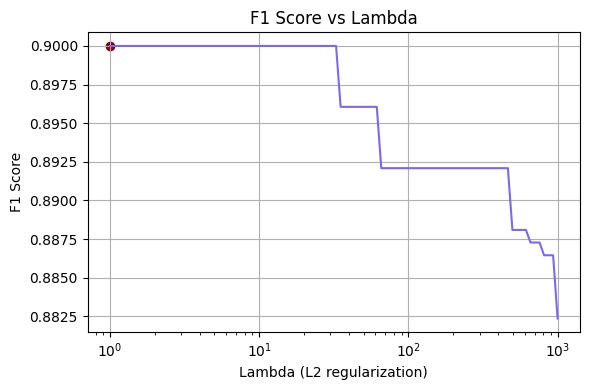


Mejor λ encontrado: 1.0 (F1 = 0.9000)


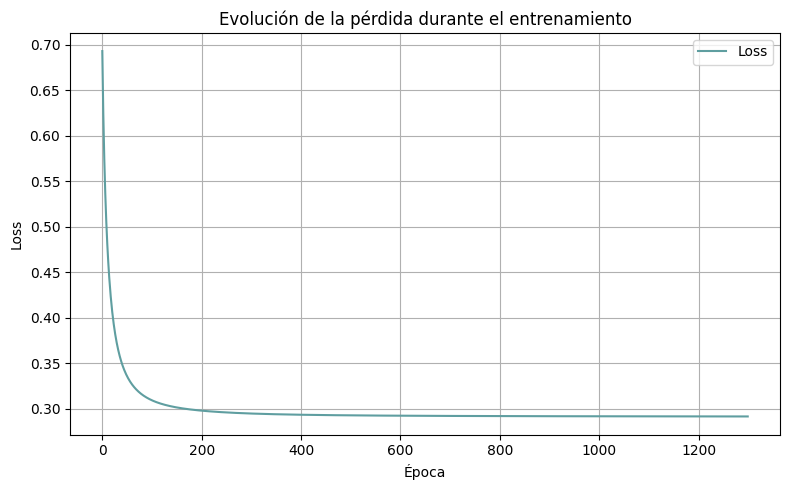


Evaluación en conjunto de validación:


### Métricas de Evaluación para el conjunto de **Validación** del set **Cell Diagnosis**
| Métrica   |   Valor |
|:----------|--------:|
| Accuracy  |  0.9159 |
| Precision |  0.8630 |
| Recall    |  0.9403 |
| F1 Score  |  0.9000 |
| AUC-ROC   |  0.9359 |
| AUC-PR    |  0.8300 |

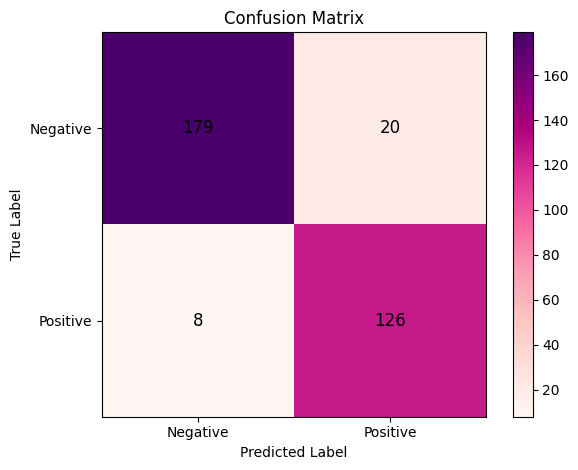

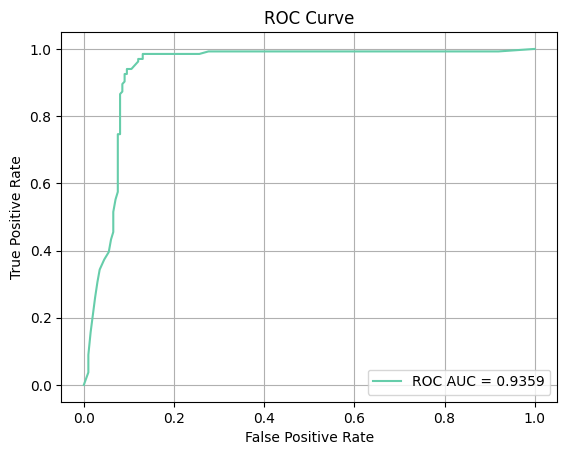

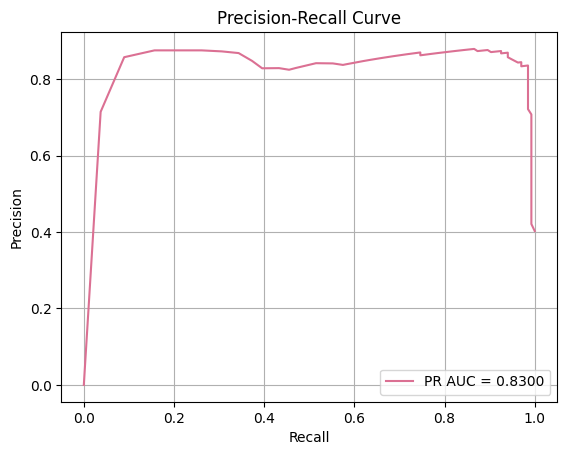

In [24]:
diagnosis_train_df, diagnosis_val_df = split_train_validation(diagnosis_dev_filled_OHE_BE, val_ratio=0.2, seed=RANDOM_STATE)

diagnosis_normalized_train, dev_train_stats = normalize_dataframe(diagnosis_train_df, is_training=True, target_col=TARGET_COLUMN)
diagnosis_normalized_val, _ = normalize_dataframe(diagnosis_val_df, is_training=False, stats=dev_train_stats, target_col=TARGET_COLUMN)


# trv - train-validation
X_train_trv = diagnosis_normalized_train.drop(columns=[TARGET_COLUMN]).values
y_train_trv = diagnosis_normalized_train[TARGET_COLUMN].values
X_val_trv = diagnosis_normalized_val.drop(columns=[TARGET_COLUMN]).values
y_val_trv = diagnosis_normalized_val[TARGET_COLUMN].values

# Búsqueda del mejor lambda (L2)
best_f1_trv = -1
best_lambda_trv = None
f1_scores_trv = []
# lambda_values = [0.0, 0.01, 0.1, 1.0, 10.0]
lambda_values = np.logspace(0, 3, 100)

print("Tuning del hiperparámetro λ (L2):")

for lmbd in lambda_values:
    model_train_val = LogisticRegression(
        learning_rate=0.1,
        iterations=1000,
        l2=lmbd,
        plot_loss=False
    )
    model_train_val.fit(X_train_trv, y_train_trv)
    y_val_pred = model_train_val.predict(X_val_trv)

    f1_trv = f1_score(y_val_trv, y_val_pred)
    f1_scores_trv.append(f1_trv)

    # # norma L2 de los pesos para ver efecto de la regularización
    # print(f"λ = {lmbd:.2f} -> F1-score = {f1:.4f}  |  Norma de pesos: {np.linalg.norm(model.weights):.4f}")

    if f1_trv > best_f1_trv:
        best_f1_trv = f1_trv
        best_lambda_trv = lmbd
    
    
plt.figure(figsize=(6, 4))
plt.plot(lambda_values, f1_scores_trv, c="mediumslateblue")
plt.scatter(best_lambda_trv, best_f1_trv, color='maroon', label='Best Lambda')
plt.xscale('log')
plt.xlabel("Lambda (L2 regularization)")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Lambda")
plt.grid(True)
plt.tight_layout()
plt.show()


print(f"\nMejor λ encontrado: {best_lambda_trv} (F1 = {best_f1_trv:.4f})")

final_model_trv = LogisticRegression(
    learning_rate=0.1,
    iterations=1300,
    l2=best_lambda_trv,
    plot_loss=True
)
final_model_trv.fit(X_train_trv, y_train_trv)


y_scores_trv = final_model_trv.predict_proba(X_val_trv)
y_pred_trv = (y_scores_trv >= 0.5).astype(int)

print("\nEvaluación en conjunto de validación:")
report_metrics(y_val_trv, y_scores_trv, dataset_name="Cell Diagnosis", set_type="Validación", roc_color="mediumaquamarine", pr_color="palevioletred")



### `1.3)` Performance del modelo para el conjunto de datos de test cell_diagnosis_balanced_test

In [25]:
from src.preprocessing import calculate_stats_dict

KNN imputing: 100%|██████████| 174/174 [00:00<00:00, 639.12it/s]


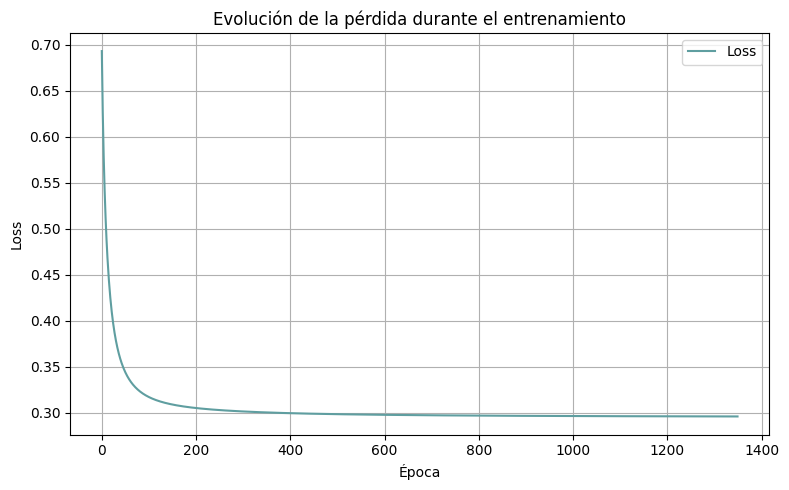


Evaluación en conjunto de test:


### Métricas de Evaluación para el conjunto de **Test** del set **Cell Diagnosis**
| Métrica   |   Valor |
|:----------|--------:|
| Accuracy  |  0.9459 |
| Precision |  0.9398 |
| Recall    |  0.9398 |
| F1 Score  |  0.9398 |
| AUC-ROC   |  0.9613 |
| AUC-PR    |  0.8719 |

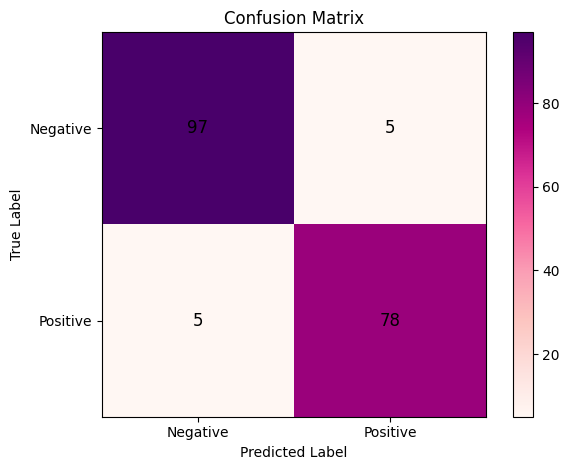

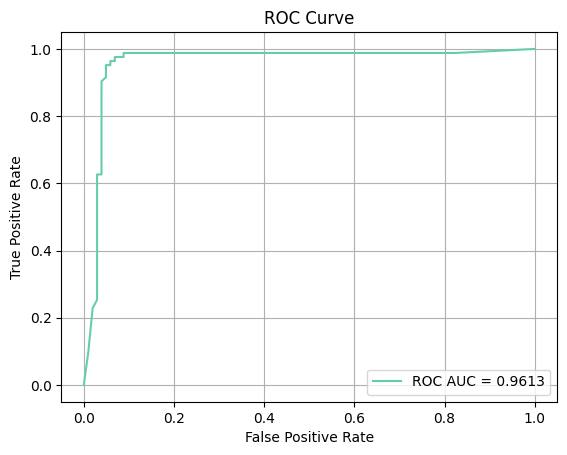

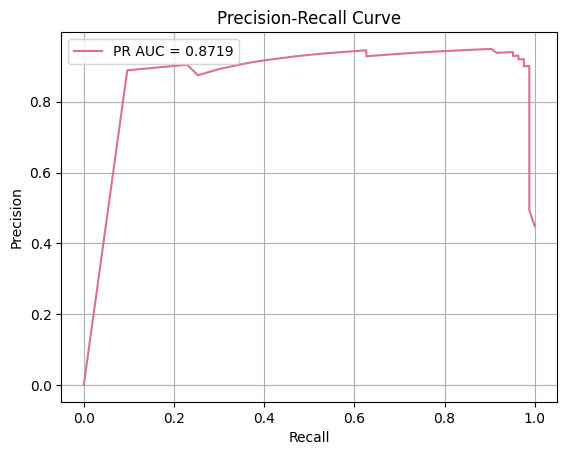

In [26]:
dev_stats_dict = calculate_stats_dict(cell_diagnosis_dev_df)

diagnosis_test_filled = handle_missing_values(
    data=cell_diagnosis_test_df,
    target_col=TARGET_COLUMN,
    train=False,
    reference=diagnosis_dev_filled,
    intervals=valid_ranges,
    stats_dict=dev_stats_dict,
    neighbors=5,
)

diagnosis_test_filled_OHE_BE = preprocess_diagnosis_data(diagnosis_test_filled)

diagnosis_dev_filled_OHE_BE_norm, dev_stats = normalize_dataframe(diagnosis_dev_filled_OHE_BE, is_training=True, target_col=TARGET_COLUMN)
diagnosis_test_filled_OHE_BE_norm, _ = normalize_dataframe(diagnosis_test_filled_OHE_BE, is_training=False, stats=dev_stats, target_col=TARGET_COLUMN)

# entreno con todo el dataset
# dt - dev-test

X_test_dt = diagnosis_test_filled_OHE_BE_norm.drop(columns=[TARGET_COLUMN])
y_test_dt = diagnosis_test_filled_OHE_BE_norm[TARGET_COLUMN]

X_train_dt = diagnosis_dev_filled_OHE_BE_norm.drop(columns=[TARGET_COLUMN])
y_train_dt = diagnosis_dev_filled_OHE_BE_norm[TARGET_COLUMN]


model = LogisticRegression(
    learning_rate=0.1,
    iterations=1350,
    l2=best_lambda_trv,
    plot_loss=True
)
model.fit(X_train_dt, y_train_dt)

y_scores_dt = model.predict_proba(X_test_dt)
y_pred_dt = (y_scores_dt >= 0.5).astype(int)

print("\nEvaluación en conjunto de test:")
report_metrics(y_test_dt, y_scores_dt, dataset_name="Cell Diagnosis", set_type="Test",  roc_color="mediumaquamarine", pr_color="palevioletred")


### `1.4)` Rebalanceo de Clases en Conjuntos Desbalanceados

##### `Cell diagnosis `*`Imbalanced`*` Dev Set`

In [27]:
diagnosis_imbalanced_train, diagnosis_imbalanced_val = split_train_validation(cell_diagnosis_imbalanced_dev_df, val_ratio=0.2, seed=RANDOM_STATE)

imbalanced_train_stats_dict = calculate_stats_dict(diagnosis_imbalanced_train)

# Train
diagnosis_imbalanced_train_filled = handle_missing_values(
    data=diagnosis_imbalanced_train,
    target_col=TARGET_COLUMN,
    train=True,
    intervals=valid_ranges,
)

diagnosis_imbalanced_train_filled_OHE_BE = preprocess_diagnosis_data(diagnosis_imbalanced_train_filled)

# Validation
diagnosis_imbalanced_val_filled = handle_missing_values(
    data=diagnosis_imbalanced_val,
    target_col=TARGET_COLUMN,
    train=False,
    reference=diagnosis_imbalanced_train_filled,
    intervals=valid_ranges,
    stats_dict=imbalanced_train_stats_dict,
)

diagnosis_imbalanced_val_filled_OHE_BE = preprocess_diagnosis_data(diagnosis_imbalanced_val_filled)


diagnosis_imbalanced_train_filled_OHE_BE_norm, imbalanced_train_stats = normalize_dataframe(diagnosis_imbalanced_train_filled_OHE_BE, is_training=True, target_col=TARGET_COLUMN)
diagnosis_imbalanced_val_filled_OHE_BE_norm, _ = normalize_dataframe(diagnosis_imbalanced_val_filled_OHE_BE, is_training=False, stats=imbalanced_train_stats, target_col=TARGET_COLUMN)

diagnosis_imbalanced_train_filled_OHE_BE_norm.to_csv('data/Problem_1/processed/cell_diagnosis_train_imbalanced_normalized.csv', index=False)
diagnosis_imbalanced_val_filled_OHE_BE_norm.to_csv('data/Problem_1/processed/cell_diagnosis_val_imbalanced_normalized.csv', index=False)


KNN imputing: 100%|██████████| 231/231 [00:00<00:00, 606.39it/s]


In [28]:
from src.rebalancing import undersampling, oversampling_duplicate_minority_class, basic_SMOTE, cost_sensitive_weights

In [29]:
# itrv - imbalanced train-validation

# 1. No rebalancing
X_train_itrv = diagnosis_imbalanced_train_filled_OHE_BE_norm.drop(columns=[TARGET_COLUMN])
y_train_itrv = diagnosis_imbalanced_train_filled_OHE_BE_norm[TARGET_COLUMN]
X_val_itrv = diagnosis_imbalanced_val_filled_OHE_BE_norm.drop(columns=[TARGET_COLUMN])
y_val_itrv = diagnosis_imbalanced_val_filled_OHE_BE_norm[TARGET_COLUMN]

# 2. Undersampling
X_train_itrv_undersampled, y_train_itrv_undersampled = undersampling(diagnosis_imbalanced_train_filled_OHE_BE_norm, TARGET_COLUMN)

# 2. Oversampling por duplicación de la clase minoritaria
X_train_itrv_oversampled, y_train_itrv_oversampled = oversampling_duplicate_minority_class(diagnosis_imbalanced_train_filled_OHE_BE_norm, TARGET_COLUMN)

# 4. SMOTE
X_train_itrv_smote, y_train_itrv_smote = basic_SMOTE(diagnosis_imbalanced_train_filled_OHE_BE_norm, columna_objetivo=TARGET_COLUMN)

# 5. Cost-sensitive weights
sample_weights_train_itrv = cost_sensitive_weights(y_train_itrv)


In [30]:
from src.metrics import accuracy, precision, recall, f1_score, plot_roc_curve, plot_pr_curve, auc

In [ ]:
def train_and_evaluate_model(X_train, y_train, X_val, y_val, sample_weights=None):
    """
    Entrena un modelo de regresión logística buscando el mejor lambda
    y evalúa su desempeño sobre el conjunto de validación.
    """
    lambda_values = np.logspace(0, 3, 100)
    best_f1 = -1
    best_lambda = None

    for lmbd in lambda_values:
        model = LogisticRegression(
            learning_rate=0.1,
            iterations=1000,
            l2=lmbd,
            plot_loss=False
        )
        model.fit(X_train, y_train, sample_weights=sample_weights)
        y_pred = model.predict(X_val)
        f1 = f1_score(y_val, y_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_lambda = lmbd

    final_model = LogisticRegression(
        learning_rate=0.1,
        iterations=1000,
        l2=best_lambda,
        plot_loss=False
    )
    final_model.fit(X_train, y_train, sample_weights=sample_weights)
    y_scores = final_model.predict_proba(X_val)
    y_pred = (y_scores >= 0.5).astype(int)

    acc = accuracy(y_val, y_pred)
    prec = precision(y_val, y_pred)
    rec = recall(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc_roc = plot_roc_curve(y_val, y_scores, show=False)
    auc_pr = plot_pr_curve(y_val, y_scores, show=False)
    plt.close() 

    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F-Score": f1,
        "AUC-ROC": auc_roc,
        "AUC-PR": auc_pr,
        "y_scores": y_scores,
        "y_true": y_val
    }
    
def evaluar_modelos_rebalanceo(X_val, y_val, train_sets: dict, dataset_name, set_type):
    """
    train_sets: diccionario con clave=str (nombre del método)
                y valor=(X_train, y_train, sample_weights o None)
    """
    resultados = []
    curvas_roc = []
    curvas_pr = []

    for nombre, (X_train, y_train, sample_weights) in train_sets.items():
        print(f"Evaluando modelo: {nombre}")
        resultado = train_and_evaluate_model(X_train, y_train, X_val, y_val, sample_weights)
        curvas_roc.append((nombre, resultado["y_true"], resultado["y_scores"]))
        curvas_pr.append((nombre, resultado["y_true"], resultado["y_scores"]))

        resultados.append({
            "Modelo": nombre,
            "Accuracy": resultado["Accuracy"],
            "Precision": resultado["Precision"],
            "Recall": resultado["Recall"],
            "F-Score": resultado["F-Score"],
            "AUC-ROC": resultado["AUC-ROC"],
            "AUC-PR": resultado["AUC-PR"]
        })

    df_resultados = pd.DataFrame(resultados)
    markdown_table = df_resultados.to_markdown(index=False)
    display(Markdown(f"### Métricas de Evaluación para el conjunto de **{set_type}** del set **{dataset_name}**\n" + markdown_table))

    # ROC conjunta
    plt.figure(figsize=(6, 5))
    for nombre, y_true, y_scores in curvas_roc:
        plot_roc_curve(y_true, y_scores, label=nombre, show=False)
    plt.title("Curva ROC - Comparación de modelos")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # PR conjunta
    plt.figure(figsize=(6, 5))
    for nombre, y_true, y_scores in curvas_pr:
        plot_pr_curve(y_true, y_scores, label=nombre, show=False)
    plt.title("Curva Precision-Recall - Comparación de modelos")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return df_resultados


Evaluando modelo: Sin rebalanceo
Evaluando modelo: Undersampling
Evaluando modelo: Oversampling duplicate
Evaluando modelo: Oversampling SMOTE
Evaluando modelo: Cost re-weighting


### Métricas de Evaluación para el conjunto de **Validación** del set **Imbalanced Dev**
| Modelo                 |   Accuracy |   Precision |   Recall |   F-Score |   AUC-ROC |   AUC-PR |
|:-----------------------|-----------:|------------:|---------:|----------:|----------:|---------:|
| Sin rebalanceo         |   0.897541 |    0.75     | 0.885246 |  0.81203  |  0.944146 | 0.717084 |
| Undersampling          |   0.913934 |    0.743902 | 1        |  0.853147 |  0.945669 | 0.717195 |
| Oversampling duplicate |   0.913934 |    0.75     | 0.983607 |  0.851064 |  0.938457 | 0.698991 |
| Oversampling SMOTE     |   0.905738 |    0.731707 | 0.983607 |  0.839161 |  0.943026 | 0.699787 |
| Cost re-weighting      |   0.909836 |    0.740741 | 0.983607 |  0.84507  |  0.943788 | 0.714312 |

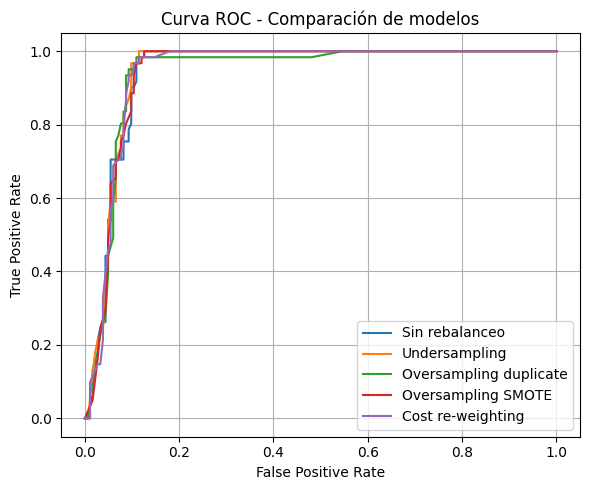

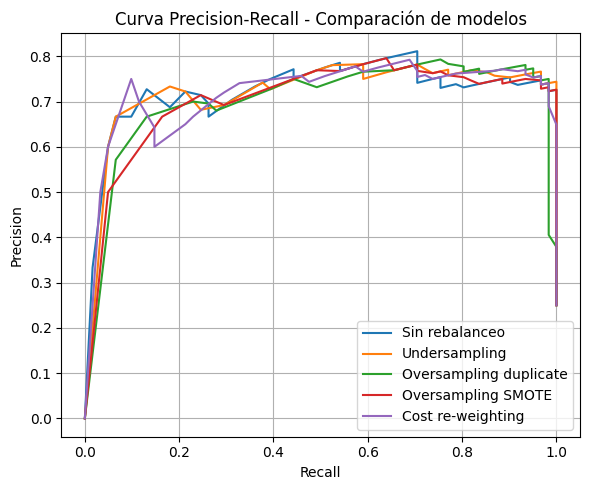

In [32]:
train_sets_itrv = {
    "Sin rebalanceo": (
        X_train_itrv.values, 
        y_train_itrv.values, 
        None
    ),
    "Undersampling": (
        X_train_itrv_undersampled.values, 
        y_train_itrv_undersampled.values, 
        None
    ),
    "Oversampling duplicate": (
        X_train_itrv_oversampled.values, 
        y_train_itrv_oversampled.values, 
        None
    ),
    "Oversampling SMOTE": (
        X_train_itrv_smote.values, 
        y_train_itrv_smote.values, 
        None
    ),
    "Cost re-weighting": (
        X_train_itrv.values, 
        y_train_itrv.values, 
        sample_weights_train_itrv
    ),
}

tabla_resultados_itrv = evaluar_modelos_rebalanceo(X_val_itrv.values, y_val_itrv.values, train_sets_itrv, "Imbalanced Dev", "Validación")

### `1.5)` Evaluar la performance los modelos desarrollados en el set de Imbalanced Test

KNN imputing: 100%|██████████| 128/128 [00:00<00:00, 582.88it/s]


Evaluando modelo: Sin rebalanceo
Evaluando modelo: Undersampling
Evaluando modelo: Oversampling duplicate
Evaluando modelo: Oversampling SMOTE
Evaluando modelo: Cost re-weighting


### Métricas de Evaluación para el conjunto de **Test** del set **Imbalanced**
| Modelo                 |   Accuracy |   Precision |   Recall |   F-Score |   AUC-ROC |   AUC-PR |
|:-----------------------|-----------:|------------:|---------:|----------:|----------:|---------:|
| Sin rebalanceo         |   0.941176 |    0.861111 | 0.911765 |  0.885714 |  0.967272 | 0.786394 |
| Undersampling          |   0.955882 |    0.85     | 1        |  0.918919 |  0.963668 | 0.769869 |
| Oversampling duplicate |   0.955882 |    0.85     | 1        |  0.918919 |  0.968426 | 0.783152 |
| Oversampling SMOTE     |   0.955882 |    0.85     | 1        |  0.918919 |  0.965975 | 0.778634 |
| Cost re-weighting      |   0.955882 |    0.85     | 1        |  0.918919 |  0.965254 | 0.774986 |

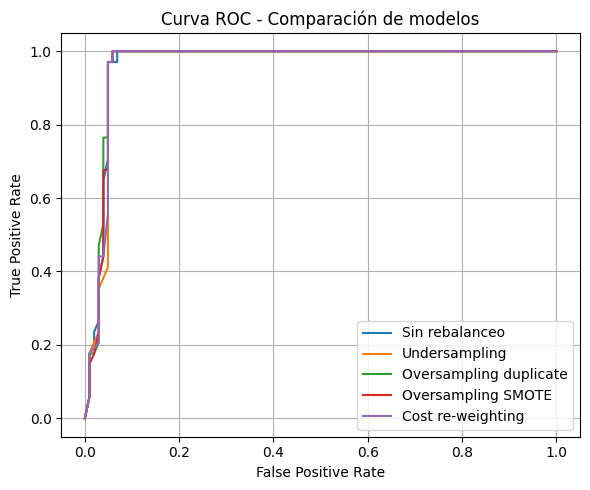

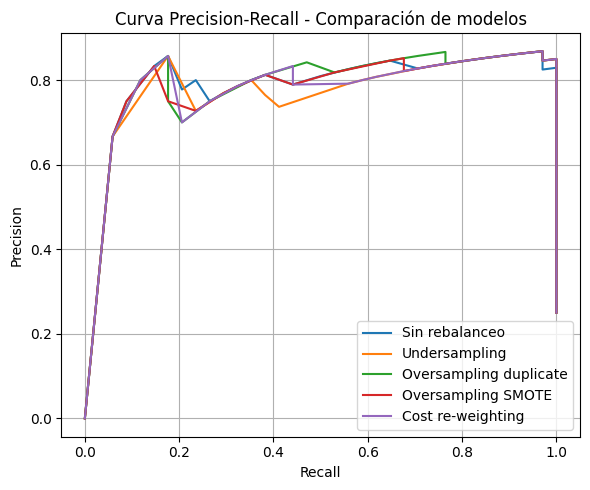

In [33]:
imbalanced_dev_stats_dict = calculate_stats_dict(cell_diagnosis_imbalanced_dev_df)

diagnosis_imbalanced_dev_filled = handle_missing_values(
    data=cell_diagnosis_imbalanced_dev_df,
    target_col="Diagnosis",
    train=True,
    reference=None,
    intervals=valid_ranges,
    stats_dict=None,
    neighbors=5,
)
diagnosis_imbalanced_dev_filled_OHE_BE = preprocess_diagnosis_data(diagnosis_imbalanced_dev_filled)


diagnosis_imbalanced_test_filled = handle_missing_values(
    data=cell_diagnosis_imbalanced_test_df,
    target_col=TARGET_COLUMN,
    train=False,
    reference=diagnosis_imbalanced_dev_filled,
    intervals=valid_ranges,
    stats_dict=imbalanced_dev_stats_dict,
    neighbors=5,
)

diagnosis_imbalanced_test_filled_OHE_BE = preprocess_diagnosis_data(diagnosis_imbalanced_test_filled)

diagnosis_imbalanced_dev_filled_OHE_BE_norm, imbalanced_dev_stats = normalize_dataframe(diagnosis_imbalanced_dev_filled_OHE_BE, is_training=True, target_col=TARGET_COLUMN)
diagnosis_imbalanced_test_filled_OHE_BE_norm, _ = normalize_dataframe(diagnosis_imbalanced_test_filled_OHE_BE, is_training=False, stats=imbalanced_dev_stats, target_col=TARGET_COLUMN)

# entrenar con todo el dataset
# idt - imbalanced dev-test

X_test_idt = diagnosis_imbalanced_test_filled_OHE_BE_norm.drop(columns=[TARGET_COLUMN])
y_test_idt = diagnosis_imbalanced_test_filled_OHE_BE_norm[TARGET_COLUMN]

X_train_idt = diagnosis_imbalanced_dev_filled_OHE_BE_norm.drop(columns=[TARGET_COLUMN])
y_train_idt = diagnosis_imbalanced_dev_filled_OHE_BE_norm[TARGET_COLUMN]


# 2. Undersampling
X_train_idt_undersampled, y_train_idt_undersampled = undersampling(diagnosis_imbalanced_dev_filled_OHE_BE_norm, TARGET_COLUMN)

# 2. Oversampling por duplicación de la clase minoritaria
X_train_idt_oversampled, y_train_idt_oversampled = oversampling_duplicate_minority_class(diagnosis_imbalanced_dev_filled_OHE_BE_norm, TARGET_COLUMN)

# 4. SMOTE
X_train_idt_smote, y_train_idt_smote = basic_SMOTE(diagnosis_imbalanced_dev_filled_OHE_BE_norm, columna_objetivo=TARGET_COLUMN)

# 5. Cost-sensitive weights
sample_weights_train_idt = cost_sensitive_weights(y_train_idt)

train_sets_idt = {
    "Sin rebalanceo": (
        X_train_idt.values, 
        y_train_idt.values, 
        None
    ),
    "Undersampling": (
        X_train_idt_undersampled.values, 
        y_train_idt_undersampled.values, 
        None
    ),
    "Oversampling duplicate": (
        X_train_idt_oversampled.values, 
        y_train_idt_oversampled.values, 
        None
    ),
    "Oversampling SMOTE": (
        X_train_idt_smote.values, 
        y_train_idt_smote.values, 
        None
    ),
    "Cost re-weighting": (
        X_train_idt.values, 
        y_train_idt.values, 
        sample_weights_train_idt
    ),
}

tabla_resultados_idt = evaluar_modelos_rebalanceo(X_test_idt.values, y_test_idt.values, train_sets_idt, "Imbalanced", "Test")

### `1.6)` Análisis de los resultados obtenidos

## 2. **Predicción de Rendimiento de Jugadores de Basketball**

### `2.1)` Análisis exploratorio sobre los datos en WAR_class_dev.csv. 
Visualice la distribución de las variables y de la variable objetivo. Verifique si hay valores
faltantes (NaN), datos duplicados o desbalanceo entre clases. Analice también la
posible presencia de correlaciones fuertes entre los features.

##### Cargar data

In [ ]:
dev_path_2 = "data/Problem_2/raw/WAR_class_dev.csv"
test_path_2 = "data/Problem_1/raw/cell_diagnosis_test.csv"

cell_diagnosis_dev_df = pd.read_csv(dev_path_2, na_values=["NaN", "N/A", ""])
cell_diagnosis_test_df = pd.read_csv(test_path_2, na_values=["NaN", "N/A", ""])